# The full building system

Grid, PV, battery, heat pump, a heat buffer and the 5R1C zone in one solve.
The week is 16 - 22 March: cold enough to need heating, sunny enough for the
PV to matter.

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from esmkit import SystemSpec, build_system, node_results, objective_value, solve

In [2]:
params = json.load(open("../test/data/golden/zone_params_year.json"))
frame = pd.read_csv(
    "../test/data/golden/zone_inputs_year.csv.gz", index_col=0, parse_dates=True
)
frame.index = frame.index.tz_convert("Europe/Berlin")

week = frame.iloc[24 * 74 : 24 * 74 + 168]
index = week.index

print(index[0], "->", index[-1])
print("T_e  min {:.1f}  mean {:.1f}  max {:.1f} degC".format(
    week["T_e"].min(), week["T_e"].mean(), week["T_e"].max()))

2010-03-16 00:30:00+01:00 -> 2010-03-22 23:30:00+01:00
T_e  min -5.5  mean 3.9  max 11.1 degC


In [3]:
pv_yield = np.clip(np.sin((index.hour - 6) / 12 * np.pi), 0, None)
cop = np.clip(0.40 * (35 + 273.15) / np.maximum(35.0 - week["T_e"].to_numpy(), 1.0), 1.5, 6.0)

print("COP  min {:.2f}  mean {:.2f}  max {:.2f}".format(cop.min(), cop.mean(), cop.max()))

COP  min 3.04  mean 4.02  max 5.16


In [4]:
spec = SystemSpec()
spec.add_bus("elec", carrier="electricity")
spec.add_bus("heat", carrier="heat")

spec.add_component("grid", "grid", bus="elec", import_price=0.35, export_price=0.08)
spec.add_component("pv", "pv", bus="elec", specific_yield="@pv_yield", capacity=8.0)
spec.add_component("battery", "battery", bus_in="elec", bus_out="elec", capacity=10.0)
spec.add_component("hp", "heat_pump", bus_in="elec", bus_out="heat", cop="@cop")
spec.add_component(
    "buffer", "thermal_storage", bus_in="heat", bus_out="heat",
    capacity=20.0, standby_loss_kW=0.02,
)
spec.add_component(
    "zone",
    "zone5r1c",
    heat_bus="heat",
    T_e="@T_e",
    gain_mass="@gain_mass",
    gain_surface="@gain_surface",
    comfort_lb="@comfort_lb",
    comfort_ub="@comfort_ub",
    C_m=params["C_m"],
    H=params["H"],
    H_door=params["H_door"],
    H_is=params["H_is"],
    H_ms=params["H_ms"],
    max_load=params["max_load"],
    design_capacity=params["design_capacity"],
)

inputs = {
    "pv_yield": pv_yield,
    "cop": cop,
    "T_e": week["T_e"].to_numpy(),
    "gain_mass": week["gain_mass"].to_numpy(),
    "gain_surface": week["gain_surface"].to_numpy(),
    "comfort_lb": np.full(len(index), 20.0),
    "comfort_ub": np.full(len(index), 22.0),
}

spec

SystemSpec(2 buses, 6 components)

In [5]:
es, nodes = build_system(spec, inputs, index)
model, _ = solve(es)
results = node_results(model, nodes, index=index)

zone = results["zone"]["timeseries"]
generation = results["pv"]["out_elec"]
imported = results["grid"]["out_elec"]
exported = results["grid"]["in_elec"]
charge = results["battery"]["in_elec"]
discharge = results["battery"]["out_elec"]

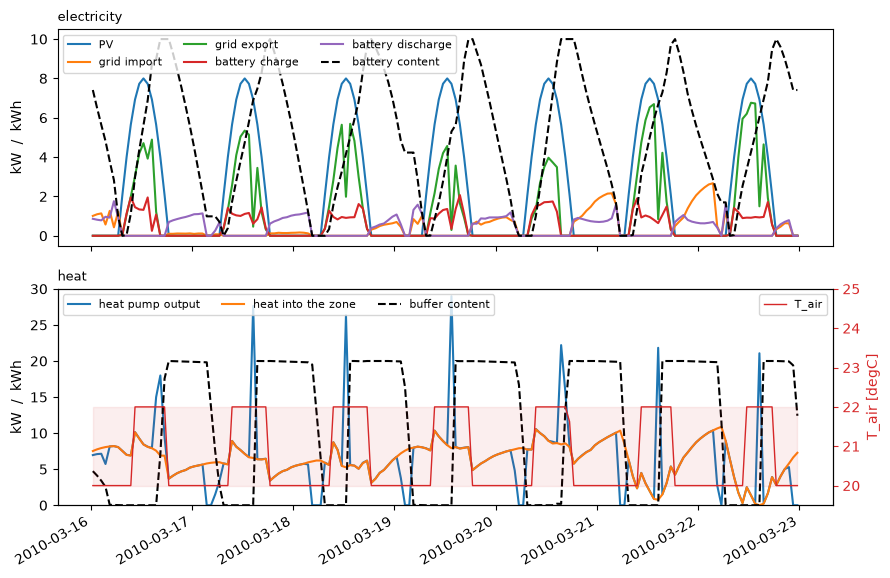

In [6]:
battery_soc = results["battery"]["storage_content"].to_numpy()[: len(index)]
buffer_soc = results["buffer"]["storage_content"].to_numpy()[: len(index)]

fig, (ax_e, ax_h) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax_e.plot(index, generation, label="PV")
ax_e.plot(index, imported, label="grid import")
ax_e.plot(index, exported, label="grid export")
ax_e.plot(index, charge, label="battery charge")
ax_e.plot(index, discharge, label="battery discharge")
ax_e.plot(index, battery_soc, label="battery content", linestyle="--", color="black")
ax_e.set_ylabel("kW  /  kWh")
ax_e.set_title("electricity", fontsize=9, loc="left")
ax_e.legend(loc="upper left", fontsize=8, ncol=3)

ax_h.plot(index, results["hp"]["out_heat"], label="heat pump output")
ax_h.plot(index, zone["Heating Load"], label="heat into the zone")
ax_h.plot(index, buffer_soc, label="buffer content", linestyle="--", color="black")
ax_h.set_ylabel("kW  /  kWh")
ax_h.set_ylim(0, 30)
ax_h.set_title("heat", fontsize=9, loc="left")
ax_h.legend(loc="upper left", fontsize=8, ncol=3)

ax_t = ax_h.twinx()
ax_t.fill_between(index, 20.0, 22.0, color="tab:red", alpha=0.08)
ax_t.plot(index, zone["T_air"], color="tab:red", linewidth=1.0, label="T_air")
ax_t.set_ylabel("T_air [degC]", color="tab:red")
ax_t.tick_params(axis="y", colors="tab:red")
ax_t.set_ylim(19.5, 25.0)
ax_t.legend(loc="upper right", fontsize=8)

fig.autofmt_xdate()
plt.show()

In [7]:
print("objective              : {:8.2f} EUR".format(objective_value(model)))
print("grid import            : {:8.2f} kWh".format(imported.sum()))
print("grid export            : {:8.2f} kWh".format(exported.sum()))
print("PV generation          : {:8.2f} kWh".format(generation.sum()))
print("PV self-consumed       : {:8.2f} kWh ({:.0f} %)".format(
    generation.sum() - exported.sum(),
    100 * (generation.sum() - exported.sum()) / generation.sum()))
print("heat pump electricity  : {:8.2f} kWh".format(results["hp"]["in_elec"].sum()))
print("heat into the zone     : {:8.2f} kWh".format(zone["Heating Load"].sum()))
print()
print("battery throughput     : {:8.2f} kWh ({:.1f} equivalent cycles)".format(
    charge.sum(), charge.sum() / 10.0))
print("buffer throughput      : {:8.2f} kWh ({:.1f} equivalent cycles)".format(
    results["buffer"]["in_heat"].sum(), results["buffer"]["in_heat"].sum() / 20.0))
print("T_air range            : {:.2f} - {:.2f} degC".format(
    zone["T_air"].min(), zone["T_air"].max()))
print("max_load_violation     : {:.2e}".format(results["zone"]["max_load_violation"]))

objective              :     5.56 EUR
grid import            :    62.35 kWh
grid export            :   203.29 kWh
PV generation          :   425.36 kWh
PV self-consumed       :   222.07 kWh (52 %)
heat pump electricity  :   277.24 kWh
heat into the zone     :  1084.45 kWh

battery throughput     :    73.68 kWh (7.4 equivalent cycles)
buffer throughput      :   149.22 kWh (7.5 equivalent cycles)
T_air range            : 20.00 - 22.00 degC
max_load_violation     : 4.21e-16
